# Model 1A, Linear Discriminant Analysis Experiment 01

This append-only experiment applies Linear Discriminant Analysis (LDA) to CatBoost 1A-04's exact 41-field manifest. It preserves the full-history rotation data, 24-hour long-turn mask, compact airport-wide W60 backlog, and five same-airline W60 fields.

The experiment compares ordinary LDA with shrinkage LDA. Shrinkage stabilizes the shared covariance estimate when one-hot, numeric, rotation, and backlog predictors are correlated. Solver and shrinkage are selected using five expanding 2019 folds. The operating threshold is selected from held-out 2019 probabilities, the frozen model is evaluated once on 2023, and 2024 is not loaded.


In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"
BACKLOG_WINDOW_MINUTES = 60
LONG_TURN_HOURS = 24
RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 1

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"scikit-learn {sklearn.__version__}")


scikit-learn 1.9.0


## Pair and validate the three established feature datasets

The rotation, airport-backlog, and same-airline-backlog datasets are paired only after exact row-identity and cutoff validation. No combined dataset is written.


In [2]:
def find_project_root(start: Path) -> Path:
    required = [
        Path("data/features") / f"{AIRPORT}_{year}_departures_{kind}.csv"
        for year in (TRAIN_YEAR, VALIDATION_YEAR)
        for kind in (
            "rotation_full_history",
            f"backlog_w{BACKLOG_WINDOW_MINUTES}",
            f"backlog_airline_w{BACKLOG_WINDOW_MINUTES}",
        )
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required experiment files: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
rotation_frames, backlog_frames, airline_backlog_frames = {}, {}, {}
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    feature_dir = PROJECT_ROOT / "data/features"
    rotation_path = feature_dir / f"{AIRPORT}_{year}_departures_rotation_full_history.csv"
    backlog_path = feature_dir / f"{AIRPORT}_{year}_departures_backlog_w{BACKLOG_WINDOW_MINUTES}.csv"
    airline_path = feature_dir / f"{AIRPORT}_{year}_departures_backlog_airline_w{BACKLOG_WINDOW_MINUTES}.csv"
    rotation_frames[partition] = pd.read_csv(rotation_path, low_memory=False)
    backlog_frames[partition] = pd.read_csv(backlog_path, low_memory=False)
    airline_backlog_frames[partition] = pd.read_csv(airline_path, low_memory=False)
    print(f"{partition:10s}: {len(rotation_frames[partition]):,} rotation rows <- {rotation_path.name}")
    print(f"{'':10s}  {len(backlog_frames[partition]):,} airport backlog rows <- {backlog_path.name}")
    print(f"{'':10s}  {len(airline_backlog_frames[partition]):,} airline backlog rows <- {airline_path.name}")


training  : 107,430 rotation rows <- JFK_2019_departures_rotation_full_history.csv
            107,430 airport backlog rows <- JFK_2019_departures_backlog_w60.csv
            107,430 airline backlog rows <- JFK_2019_departures_backlog_airline_w60.csv


validation: 109,983 rotation rows <- JFK_2023_departures_rotation_full_history.csv
            109,983 airport backlog rows <- JFK_2023_departures_backlog_w60.csv
            109,983 airline backlog rows <- JFK_2023_departures_backlog_airline_w60.csv


In [3]:
ROTATION_FEATURES = [
    "ROTATION_STATUS", "ROTATION_MATCH_FOUND", "ROTATION_INBOUND_ORIGIN",
    "ROTATION_SCHEDULED_TURN_MINUTES",
    "ROTATION_INBOUND_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_OVERDUE_MINUTES",
    "ROTATION_LOG_INBOUND_OVERDUE_MINUTES",
    "ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_LOG_ACTUAL_TURN_MINUTES",
    "ROTATION_INBOUND_ARR_DELAY", "ROTATION_INBOUND_DELAYED_15",
    "ROTATION_LOG_SCHEDULED_TURN_MINUTES",
]
ROTATION_AUDIT_COLUMNS = [
    "ROTATION_TARGET_CUTOFF_UTC", "ROTATION_PRIOR_REPORTING_AIRLINE",
    "ROTATION_PRIOR_FLIGHT_NUMBER", "ROTATION_PRIOR_FLIGHT_DATE",
    "ROTATION_PRIOR_SCHEDULED_DEPARTURE_UTC",
    "ROTATION_PRIOR_SCHEDULED_ARRIVAL_UTC",
    "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC",
    "ROTATION_SCHEDULE_RECONSTRUCTION_ERROR_MINUTES",
]
BACKLOG_PREFIX = f"BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_SCHEDULED_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{BACKLOG_PREFIX}_DELAY_RATE", f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
]
COMPACT_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
]
AIRLINE_BACKLOG_PREFIX = f"AIRLINE_BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_AIRLINE_BACKLOG_FEATURES = [
    f"{AIRLINE_BACKLOG_PREFIX}_SCHEDULED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAY_RATE",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{AIRLINE_BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_SHARE",
]
SELECTED_AIRLINE_BACKLOG_FEATURES = [
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAY_RATE",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_SHARE",
]
IDENTITY_COLUMNS = [
    "FlightDate", "Reporting_Airline", "Flight_Number_Reporting_Airline",
    "Origin", "Dest", "CRSDepTime", "Tail_Number", TARGET,
]

combined_frames, source_rows = {}, []
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    rotation = rotation_frames[partition]
    backlog = backlog_frames[partition]
    airline_backlog = airline_backlog_frames[partition]
    required_rotation = {"FlightDate", "DATE", "Origin", TARGET, *ROTATION_FEATURES, *ROTATION_AUDIT_COLUMNS}
    required_backlog = {"FlightDate", "DATE", "Origin", TARGET, *FULL_BACKLOG_FEATURES}
    required_airline = {"FlightDate", "DATE", "Origin", TARGET, *FULL_AIRLINE_BACKLOG_FEATURES}
    assert not required_rotation.difference(rotation.columns)
    assert not required_backlog.difference(backlog.columns)
    assert not required_airline.difference(airline_backlog.columns)
    assert len(rotation) == len(backlog) == len(airline_backlog)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], backlog[IDENTITY_COLUMNS], check_dtype=False)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], airline_backlog[IDENTITY_COLUMNS], check_dtype=False)
    rotation["FlightDate"] = pd.to_datetime(rotation["FlightDate"], errors="raise")
    backlog["FlightDate"] = pd.to_datetime(backlog["FlightDate"], errors="raise")
    airline_backlog["FlightDate"] = pd.to_datetime(airline_backlog["FlightDate"], errors="raise")
    cutoff = pd.to_datetime(backlog["DATE"], errors="raise")
    airline_cutoff = pd.to_datetime(airline_backlog["DATE"], errors="raise")
    pd.testing.assert_series_equal(cutoff, airline_cutoff, check_names=False)
    assert rotation["FlightDate"].dt.year.eq(year).all() and rotation["Origin"].eq(AIRPORT).all()

    match = pd.to_numeric(rotation["ROTATION_MATCH_FOUND"], errors="raise")
    arrived = pd.to_numeric(rotation["ROTATION_INBOUND_ARRIVED_BY_CUTOFF"], errors="raise")
    not_arrived = pd.to_numeric(rotation["ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF"], errors="raise")
    assert match.eq(arrived + not_arrived).all()
    actual_only = ["ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_INBOUND_ARR_DELAY",
                   "ROTATION_INBOUND_DELAYED_15", "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC"]
    assert not rotation.loc[arrived.eq(0), actual_only].notna().any().any()

    scheduled, completed, pending, delayed_count = (
        pd.to_numeric(backlog[column], errors="raise") for column in FULL_BACKLOG_FEATURES[:4]
    )
    assert scheduled.eq(completed + pending).all() and delayed_count.le(completed).all()
    same_cutoff_variants = (backlog.assign(_CUTOFF=cutoff)
        .groupby("_CUTOFF", sort=False)[FULL_BACKLOG_FEATURES]
        .nunique(dropna=False).to_numpy().max(initial=0))
    assert same_cutoff_variants <= 1

    airline_scheduled, airline_completed, airline_pending, airline_delayed = (
        pd.to_numeric(airline_backlog[column], errors="raise")
        for column in FULL_AIRLINE_BACKLOG_FEATURES[:4]
    )
    airline_share = pd.to_numeric(airline_backlog[FULL_AIRLINE_BACKLOG_FEATURES[-1]], errors="coerce")
    assert airline_scheduled.eq(airline_completed + airline_pending).all()
    assert airline_delayed.le(airline_completed).all()
    has_airline_history = airline_scheduled.gt(0)
    assert airline_share.loc[~has_airline_history].isna().all()
    assert np.allclose(
        airline_share.loc[has_airline_history],
        airline_pending.loc[has_airline_history] / airline_scheduled.loc[has_airline_history],
    )
    normalized_airline = airline_backlog["Reporting_Airline"].astype("string").str.strip().str.upper()
    same_airline_cutoff_variants = (airline_backlog.assign(_CUTOFF=airline_cutoff, _AIRLINE=normalized_airline)
        .groupby(["_AIRLINE", "_CUTOFF"], sort=False)[FULL_AIRLINE_BACKLOG_FEATURES]
        .nunique(dropna=False).to_numpy().max(initial=0))
    assert same_airline_cutoff_variants <= 1

    combined = rotation.copy()
    for column in COMPACT_BACKLOG_FEATURES:
        combined[column] = backlog[column].to_numpy()
    for column in FULL_AIRLINE_BACKLOG_FEATURES:
        combined[column] = airline_backlog[column].to_numpy()
    combined_frames[partition] = combined
    source_rows.append({
        "partition": partition, "year": year, "rows": len(combined),
        "delay_rate": combined[TARGET].mean(), "rotation_match_rate": match.mean(),
        "not_arrived_rows": int(not_arrived.sum()), "mean_airport_pending": pending.mean(),
        "mean_airline_pending": airline_pending.mean(),
        "airline_pending_rows": int(airline_pending.gt(0).sum()),
        "airport_cutoff_violations": int(same_cutoff_variants > 1),
        "airline_cutoff_violations": int(same_airline_cutoff_variants > 1),
    })
source_summary = pd.DataFrame(source_rows).set_index("partition")
source_summary


,year,rows,delay_rate,rotation_match_rate,not_arrived_rows,mean_airport_pending,mean_airline_pending,airline_pending_rows,airport_cutoff_violations,airline_cutoff_violations
partition,,,,,,,,,,
training,2019,107430,0.1877,0.9665,3133,2.4552,0.5685,36464,0,0
validation,2023,109983,0.2364,0.9554,3565,3.0245,0.7171,43531,0,0


## Apply the 24-hour rotation mask and select CatBoost 04's exact manifest

The long-turn sensitivity rule and all 41 source fields match the preferred departure model. LDA changes only the classifier and its preprocessing.


In [4]:
def mask_long_turns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    long_turn = pd.to_numeric(result["ROTATION_SCHEDULED_TURN_MINUTES"], errors="coerce").gt(LONG_TURN_HOURS * 60)
    result.loc[long_turn, ROTATION_FEATURES] = np.nan
    result.loc[long_turn, "ROTATION_STATUS"] = "LONG_TURN_EXCLUDED"
    return result


model_frames = {partition: mask_long_turns(frame) for partition, frame in combined_frames.items()}
BASE_CATEGORICAL_FEATURES = ["Month", "DayOfWeek", "Reporting_Airline", "Dest"]
BASE_NUMERIC_FEATURES = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES", "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES", "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES", "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature", "HourlyDryBulbTemperature",
    "HourlyPrecipitation", "HourlyRelativeHumidity",
    "HourlyVisibility", "HourlyWindSpeed",
]
ROTATION_CATEGORICAL = ["ROTATION_STATUS", "ROTATION_INBOUND_ORIGIN"]
ROTATION_NUMERIC = [column for column in ROTATION_FEATURES if column not in ROTATION_CATEGORICAL]
categorical_features = [*BASE_CATEGORICAL_FEATURES, *ROTATION_CATEGORICAL]
shared_numeric_features = [*BASE_NUMERIC_FEATURES, *ROTATION_NUMERIC, *COMPACT_BACKLOG_FEATURES]
variant_features = {
    "CatBoost 02 control": [*categorical_features, *shared_numeric_features],
    "plus same-airline W60": [
        *categorical_features, *shared_numeric_features, *SELECTED_AIRLINE_BACKLOG_FEATURES
    ],
}
all_numeric_features = [*shared_numeric_features, *SELECTED_AIRLINE_BACKLOG_FEATURES]
required_columns = list(dict.fromkeys([
    "FlightDate", "CRSDepTime", TARGET, *categorical_features, *all_numeric_features
]))
assert len(categorical_features) == 6 and len(shared_numeric_features) == 30
assert len(variant_features["CatBoost 02 control"]) == 36
assert len(variant_features["plus same-airline W60"]) == 41
for partition, frame in model_frames.items():
    assert not set(required_columns).difference(frame.columns), partition
forbidden = {
    TARGET, "DepTime", "DepDelay", "DepDelayMinutes", "TaxiOut",
    "WheelsOff", "WheelsOn", "TaxiIn", "ArrTime", "ArrDelay",
    "ArrDelayMinutes", "ArrDel15", "ActualElapsedTime", "AirTime",
    "Tail_Number", *ROTATION_AUDIT_COLUMNS,
}
assert not forbidden.intersection(set().union(*map(set, variant_features.values())))
pd.DataFrame({
    name: {"source fields": len(columns), "categorical": len(categorical_features),
           "numeric": len(columns) - len(categorical_features),
           "airport backlog fields": len([c for c in columns if c.startswith(BACKLOG_PREFIX)]),
           "airline backlog fields": len([c for c in columns if c.startswith(AIRLINE_BACKLOG_PREFIX)])}
    for name, columns in variant_features.items()
}).T


SELECTED_MANIFEST = "plus same-airline W60"
feature_columns = variant_features[SELECTED_MANIFEST]
numeric_features = [column for column in feature_columns if column not in categorical_features]
assert len(feature_columns) == 41
assert len(categorical_features) == 6 and len(numeric_features) == 35
print(f"Selected manifest: {SELECTED_MANIFEST}")
print(f"Source fields: {len(feature_columns)} ({len(categorical_features)} categorical, {len(numeric_features)} numeric)")

Selected manifest: plus same-airline W60
Source fields: 41 (6 categorical, 35 numeric)


In [5]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    for column in categorical_features:
        frame[column] = frame[column].astype("string").fillna("MISSING").astype(str)
    for column in all_numeric_features:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


train_model_df = prepare_model_frame(model_frames["training"])
validation_model_df = prepare_model_frame(model_frames["validation"])
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)
X_train_variants = {
    name: train_model_df[columns].reset_index(drop=True)
    for name, columns in variant_features.items()
}
X_validation_variants = {
    name: validation_model_df[columns].reset_index(drop=True)
    for name, columns in variant_features.items()
}
assert training_dates.max() < validation_dates.min()
missing_summary = pd.DataFrame({
    "training_missing": train_model_df[all_numeric_features].isna().sum(),
    "validation_missing": validation_model_df[all_numeric_features].isna().sum(),
})
missing_summary[missing_summary.sum(axis=1).gt(0)]


X_train = X_train_variants[SELECTED_MANIFEST]
X_validation = X_validation_variants[SELECTED_MANIFEST]
assert X_train.shape == (len(y_train), 41)
assert X_validation.shape == (len(y_validation), 41)

In [6]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    day_blocks = np.array_split(np.array(sorted(pd.unique(normalized))), n_splits + 1)
    splits, rows = [], []
    for fold in range(1, n_splits + 1):
        train_days, heldout_days = np.concatenate(day_blocks[:fold]), day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold, "train_rows": len(train_idx), "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })
    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(training_dates, y_train, N_TIME_SPLITS)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17737,18776,2019-03-02,2019-03-03,2019-05-02,0.1892,0.1674
2,36513,18150,2019-05-02,2019-05-03,2019-07-02,0.1780,0.2072
3,54663,17758,2019-07-02,2019-07-03,2019-09-01,0.1877,0.2577
4,72421,17686,2019-09-01,2019-09-02,2019-11-01,0.2048,0.1384
5,90107,17323,2019-11-01,2019-11-02,2019-12-31,0.1918,0.1666


## Fold-local preprocessing and LDA search

Categorical fields are mode-imputed and one-hot encoded. Numeric fields are median-imputed with missingness indicators and standardized. Every learned transformation remains inside each chronological fold.

The search compares SVD LDA without shrinkage and covariance-based LDA with no, automatic, or fixed shrinkage. Mean temporal average precision selects the configuration.


In [7]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])
preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", numeric_pipeline, numeric_features),
], remainder="drop", sparse_threshold=0.0)

lda_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LinearDiscriminantAnalysis()),
])

parameter_grid = [
    {"classifier__solver": ["svd"], "classifier__shrinkage": [None]},
    {
        "classifier__solver": ["lsqr"],
        "classifier__shrinkage": [None, "auto", 0.01, 0.10, 0.50],
    },
    {
        "classifier__solver": ["eigen"],
        "classifier__shrinkage": ["auto", 0.01, 0.10, 0.50],
    },
]
scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "neg_brier": "neg_brier_score",
}

grid_search = GridSearchCV(
    lda_pipeline,
    parameter_grid,
    scoring=scoring,
    refit="average_precision",
    cv=temporal_splits,
    n_jobs=N_JOBS,
    pre_dispatch=N_JOBS,
    verbose=0,
    return_train_score=False,
    error_score="raise",
)

candidate_count = len(list(ParameterGrid(parameter_grid)))
print(f"LDA configurations: {candidate_count}")
print(f"Temporal search fits: {candidate_count * N_TIME_SPLITS}")


LDA configurations: 10
Temporal search fits: 50


In [8]:
search_start = perf_counter()
grid_search.fit(X_train, y_train)
search_seconds = perf_counter() - search_start
best_pipeline = grid_search.best_estimator_

cv_results = pd.DataFrame(grid_search.cv_results_)
result_columns = [
    "rank_test_average_precision",
    "mean_test_average_precision",
    "std_test_average_precision",
    "mean_test_roc_auc",
    "mean_test_neg_brier",
    "param_classifier__solver",
    "param_classifier__shrinkage",
]

print(f"Search and all-2019 refit completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal AP: {grid_search.best_score_:.4f}")
print(f"Selected parameters: {grid_search.best_params_}")
cv_results.sort_values("rank_test_average_precision")[result_columns]


Search and all-2019 refit completed in 18.5 seconds
Best mean temporal AP: 0.6566
Selected parameters: {'classifier__shrinkage': 0.01, 'classifier__solver': 'lsqr'}


,rank_test_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_test_neg_brier,param_classifier__solver,param_classifier__shrinkage
3,1,0.6566,0.0579,0.8166,-0.1027,lsqr,0.0100
7,1,0.6566,0.0579,0.8166,-0.1027,eigen,0.0100
0,3,0.6554,0.0584,0.8153,-0.1030,svd,None
4,4,0.6515,0.0584,0.8145,-0.1033,lsqr,0.1000
8,4,0.6515,0.0584,0.8145,-0.1033,eigen,0.1000
1,6,0.6503,0.0628,0.8118,-0.1090,lsqr,None
2,7,0.6493,0.0587,0.8129,-0.1034,lsqr,auto
6,7,0.6493,0.0587,0.8129,-0.1034,eigen,auto
5,9,0.6271,0.0605,0.8060,-0.1110,lsqr,0.5000
9,9,0.6271,0.0605,0.8060,-0.1110,eigen,0.5000


## Generate selected-model held-out probabilities and choose the threshold using 2019 only

The selected pipeline is refitted within every chronological fold. The exact thresholds on the held-out 2019 precision–recall curve are ranked by F1, with precision as the tie-breaker.


In [9]:
oof_probabilities = np.full(len(y_train), np.nan)
fold_rows = []
for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
    fold_model = clone(best_pipeline)
    fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    probabilities = fold_model.predict_proba(X_train.iloc[heldout_idx])[:, 1]
    oof_probabilities[heldout_idx] = probabilities
    fold_rows.append({
        "fold": fold_number,
        "average_precision": average_precision_score(y_train.iloc[heldout_idx], probabilities),
        "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
        "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
    })

fold_results = pd.DataFrame(fold_rows).set_index("fold")
oof_mask = np.isfinite(oof_probabilities)
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]
curve_precision, curve_recall, curve_thresholds = precision_recall_curve(oof_y, oof_p)
threshold_results = pd.DataFrame({
    "threshold": curve_thresholds,
    "precision": curve_precision[:-1],
    "recall": curve_recall[:-1],
})
threshold_results["f1"] = np.divide(
    2 * threshold_results["precision"] * threshold_results["recall"],
    threshold_results["precision"] + threshold_results["recall"],
    out=np.zeros(len(threshold_results)),
    where=(threshold_results["precision"] + threshold_results["recall"]).to_numpy() > 0,
)
selected_threshold = float(
    threshold_results.sort_values(["f1", "precision"], ascending=False).iloc[0]["threshold"]
)

print(f"Mean temporal AP: {fold_results['average_precision'].mean():.4f}")
print(f"Aggregated OOF AP: {average_precision_score(oof_y, oof_p):.4f}")
print(f"Training-selected threshold: {selected_threshold:.6f}")
display(fold_results)
threshold_results.sort_values(["f1", "precision"], ascending=False).head(10)


Mean temporal AP: 0.6566
Aggregated OOF AP: 0.6673
Training-selected threshold: 0.182804


,average_precision,roc_auc,brier_score
fold,,,
1,0.6196,0.7996,0.0975
2,0.6980,0.8285,0.1100
3,0.7481,0.8440,0.1253
4,0.5903,0.7982,0.0838
5,0.6268,0.8128,0.0969


,threshold,precision,recall,f1
74154,0.1828,0.6131,0.5667,0.5890
74153,0.1828,0.6131,0.5667,0.5890
74163,0.1831,0.6133,0.5665,0.5890
74156,0.1828,0.6131,0.5666,0.5890
74166,0.1831,0.6133,0.5664,0.5889
74152,0.1828,0.6130,0.5667,0.5889
74162,0.1831,0.6132,0.5665,0.5889
74155,0.1828,0.6131,0.5666,0.5889
74165,0.1831,0.6133,0.5664,0.5889
74158,0.1829,0.6131,0.5666,0.5889


## Evaluate the fixed model once on 2023

Only the LDA configuration and threshold selected from 2019 are evaluated on 2023. CatBoost 1A-04 is included as a fixed documented comparison.


In [10]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


validation_probabilities = best_pipeline.predict_proba(X_validation)[:, 1]
evaluation_results = pd.DataFrame([
    {
        "model": "CatBoost 1A-04 (documented)",
        "threshold": 0.31,
        "accuracy": 0.8516,
        "balanced_accuracy": 0.7598,
        "precision": 0.7327,
        "recall": 0.5858,
        "f1": 0.6511,
        "mcc": 0.5640,
        "roc_auc": 0.8546,
        "average_precision": 0.7526,
        "brier_score": 0.1086,
    },
    {
        "model": "LDA 1A-01 (default)",
        **evaluate_probabilities(y_validation, validation_probabilities, 0.50),
    },
    {
        "model": "LDA 1A-01 (training-selected)",
        **evaluate_probabilities(y_validation, validation_probabilities, selected_threshold),
    },
]).set_index("model")
evaluation_results


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
CatBoost 1A-04 (documented),0.3100,0.8516,0.7598,0.7327,0.5858,0.6511,0.5640,0.8546,0.7526,0.1086
LDA 1A-01 (default),0.5000,0.8415,0.7023,0.8009,0.4384,0.5666,0.5122,0.8261,0.7032,0.1239
LDA 1A-01 (training-selected),0.1828,0.8162,0.7438,0.6121,0.6066,0.6093,0.4892,0.8261,0.7032,0.1239


## Inspect discriminant coefficients and publishable diagnostics

LDA coefficients describe the fitted linear discriminant after imputation, encoding, scaling, and shrinkage. They show association with the classification boundary, not causal effects.


,LDA 1A Experiment 01 Appendix F values
source fields,41
prepared predictors,210
selected solver,lsqr
selected shrinkage,0.01
training CV AP,0.6566
selected threshold,0.1828
validation prevalence,0.2364
validation AP,0.7032
validation ROC AUC,0.8261
validation Brier,0.1239


,feature,coefficient,abs_coefficient
0,numeric__ROTATION_LOG_ACTUAL_TURN_MINUTES,-3.0544,3.0544
1,numeric__ROTATION_LOG_SCHEDULED_TURN_MINUTES,1.9410,1.9410
2,numeric__ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF,1.1366,1.1366
3,numeric__ROTATION_LOG_INBOUND_OVERDUE_MINUTES,-0.8660,0.8660
4,categorical__ROTATION_STATUS_NO_PRIOR_EVENT,-0.8270,0.8270
5,categorical__ROTATION_STATUS_PREVIOUS_EVENT_DE...,0.7856,0.7856
6,numeric__ROTATION_INBOUND_ARRIVED_BY_CUTOFF,-0.6184,0.6184
7,numeric__ROTATION_ACTUAL_TURN_MINUTES,0.5367,0.5367
8,numeric__ROTATION_INBOUND_DELAYED_15,0.4739,0.4739
9,categorical__Dest_CVG,-0.4484,0.4484


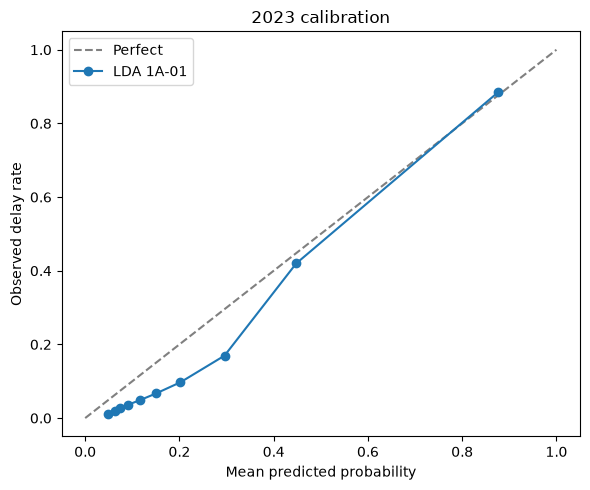

In [11]:
prepared_feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
classifier = best_pipeline.named_steps["classifier"]
coefficient_table = (
    pd.DataFrame({
        "feature": prepared_feature_names,
        "coefficient": classifier.coef_[0],
    })
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)

default = evaluation_results.loc["LDA 1A-01 (default)"]
selected = evaluation_results.loc["LDA 1A-01 (training-selected)"]
publishable = pd.Series({
    "source fields": len(feature_columns),
    "prepared predictors": len(prepared_feature_names),
    "selected solver": grid_search.best_params_["classifier__solver"],
    "selected shrinkage": str(grid_search.best_params_["classifier__shrinkage"]),
    "training CV AP": grid_search.best_score_,
    "selected threshold": selected_threshold,
    "validation prevalence": y_validation.mean(),
    "validation AP": default["average_precision"],
    "validation ROC AUC": default["roc_auc"],
    "validation Brier": default["brier_score"],
    "selected-threshold accuracy": selected["accuracy"],
    "selected-threshold balanced accuracy": selected["balanced_accuracy"],
    "selected-threshold precision": selected["precision"],
    "selected-threshold recall": selected["recall"],
    "selected-threshold F1": selected["f1"],
    "selected-threshold MCC": selected["mcc"],
    "search seconds": search_seconds,
}, name="LDA 1A Experiment 01 Appendix F values")
display(publishable.to_frame())
display(coefficient_table.head(25))

predicted, observed = calibration_curve(
    y_validation, validation_probabilities, n_bins=10, strategy="quantile"
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
ax.plot(predicted, observed, marker="o", label="LDA 1A-01")
ax.set(
    title="2023 calibration",
    xlabel="Mean predicted probability",
    ylabel="Observed delay rate",
)
ax.legend()
plt.tight_layout()
plt.show()


## Interpretation checklist

1. Does ordinary or shrinkage LDA win the 2019 temporal comparison?
2. Does LDA improve ranking, probability quality, F1, or MCC over CatBoost 1A-04?
3. Does shrinkage stabilize the correlated rotation and backlog representation?
4. Is the difference large enough to replace the preferred departure model?
5. Preserve the final-tail assignment limitation and keep 2024 untouched.
